In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import random
import time
import tracemalloc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import SpaGCN as spg
import torch

import sys
sys.path.append('/home/lytq/Spatial-Transcriptomics-Benchmark/utils')
from evaluate import evaluate_clustering
from load_st_data import load_colon_visium_hd

In [2]:
SEEDS = [42, 123, 456, 789, 2024]
SAMPLE_NAME = 'visium_hd_cancer_colon_square_016um'
N_CLUSTERS = 6

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def setup_coords(adata, library_id):
    """Map Visium HD grid + pixel coords for SpaGCN (analogous to DLPFC x2–x5)."""
    adata.obs['x_array'] = adata.obs['row'].astype(float)
    adata.obs['y_array'] = adata.obs['col'].astype(float)
    sf = adata.uns['spatial'][library_id]['scalefactors']
    scale = sf['tissue_hires_scalef']
    adata.obs['x_pixel'] = adata.obsm['spatial'][:, 0] * scale
    adata.obs['y_pixel'] = adata.obsm['spatial'][:, 1] * scale
    return adata

In [3]:
data_path = Path('/home/lytq/Spatial-Transcriptomics-Benchmark/data/colon_cancer/')
output_path = Path('/home/lytq/Spatial-Transcriptomics-Benchmark/results/colon_cancer/')
dir_input = data_path / SAMPLE_NAME
spatial_dir = dir_input / 'spatial'
library_id = SAMPLE_NAME

print(f'Loading {SAMPLE_NAME}...')
adata_raw, Ann_df = load_colon_visium_hd(dir_input, spatial_dir)

Loading visium_hd_cancer_colon_square_016um...
Loading count matrix ...
Loaded 50387 spots x 18051 genes
Ground Truth
Neoplasm                     20887
Non-neoplastic Epithelium    15207
Connective Tissue            10614
Smooth Muscle                 1713
Vessel                        1044
Veins                          922
Name: count, dtype: int64


In [4]:
seed = SEEDS[0]
set_seed(seed)

In [5]:
dir_out = output_path / f'{seed}/SpaGCN'
dir_out.mkdir(parents=True, exist_ok=True)

time_start = time.time()
tracemalloc.start()

adata = adata_raw.copy()
adata.var_names_make_unique()
adata.var_names = [i.upper() for i in adata.var_names]
adata.var['genename'] = adata.var.index.astype(str)
adata = setup_coords(adata, library_id)

x_array = adata.obs['x_array'].tolist()
y_array = adata.obs['y_array'].tolist()
x_pixel = adata.obs['x_pixel'].tolist()
y_pixel = adata.obs['y_pixel'].tolist()

b, a = 49, 1
adj = spg.calculate_adj_matrix(
    x=x_pixel, y=y_pixel,
    x_pixel=x_pixel, y_pixel=y_pixel,
    beta=b, alpha=a, histology=False,
)

spg.prefilter_genes(adata, min_cells=3)
spg.prefilter_specialgenes(adata)
sc.pp.normalize_per_cell(adata)
sc.pp.log1p(adata)

p = 0.5
# spg.test_l(adj, [1, 10, 100, 500, 1000])
# l = spg.find_l(p=p, adj=adj, start=100, end=500, sep=1, tol=0.01)

spg.test_l(adj, [0.5, 1, 2, 5, 10, 20, 50, 100, 200])
print('test_l finished')
l = spg.find_l(p=p, adj=adj, start=1, end=100, sep=0.5, tol=0.01)
if l is None:
    print('Failed 1-100')
    l = spg.search_l(p=p, adj=adj, start=0.1, end=200, tol=0.01)
if l is None:
    print("Warning: auto l search failed; using fallback l=10")
    breakpoint()
print(f"Using l = {l}")

Calculateing adj matrix using xy only...
l is  0.5 Percentage of total expression contributed by neighborhoods: 0.0
l is  1 Percentage of total expression contributed by neighborhoods: 7.712841033935547e-05
l is  2 Percentage of total expression contributed by neighborhoods: 0.28135740756988525
l is  5 Percentage of total expression contributed by neighborhoods: 6.1747846603393555
l is  10 Percentage of total expression contributed by neighborhoods: 27.441726684570312
l is  20 Percentage of total expression contributed by neighborhoods: 110.86965942382812
l is  50 Percentage of total expression contributed by neighborhoods: 665.0230102539062
l is  100 Percentage of total expression contributed by neighborhoods: 2452.62841796875
l is  200 Percentage of total expression contributed by neighborhoods: 8237.241094348581
test_l finished
L= 1.0 P= 8e-05
L= 1.5 P= 0.03225
L= 2.0 P= 0.28136
L= 2.5 P= 0.82858
L= 3.0 P= 1.5969
L= 3.5 P= 2.5267
L= 4.0 P= 3.60106
L= 4.5 P= 4.81728
L= 5.0 P= 6.17478

KeyboardInterrupt: 

In [8]:
l =  2.22296142578125
res =  0.15000000000000002

In [7]:
r_seed = t_seed = n_seed = seed
res = spg.search_res(
    adata, adj, l, N_CLUSTERS,
    start=0.3, step=0.1, tol=5e-3, lr=0.05, max_epochs=20,
    r_seed=r_seed, t_seed=t_seed, n_seed=n_seed,
)
print(f'Res = {res}')

Start at res =  0.3 step =  0.1


KeyboardInterrupt: 

In [9]:
clf = spg.SpaGCN()
clf.set_l(l)
random.seed(r_seed)
torch.manual_seed(t_seed)
np.random.seed(n_seed)
clf.train(
    adata, adj,
    init_spa=True, init='louvain', res=res,
    tol=5e-3, lr=0.05, max_epochs=200,
)
y_pred, _ = clf.predict()

Initializing cluster centers with louvain, resolution =  0.15000000000000002
Epoch  0
Epoch  10
Epoch  20
Epoch  30
Epoch  40
Epoch  50
Epoch  60
Epoch  70
Epoch  80
Epoch  90
Epoch  100
Epoch  110
Epoch  120
Epoch  130
Epoch  140
delta_label  0.004544823069442515 < tol  0.005
Reach tolerance threshold. Stopping training.
Total epoch: 142


In [10]:
y_pred

array([0, 3, 1, ..., 1, 1, 1])

In [11]:
adata.obs['pred'] = y_pred
# adata.obs['pred'] = y_pred.astype('category')

Calculateing adj matrix using xy only...
         Falling back to preprocessing with `sc.pp.pca` and default params.
ARI = 0.4221


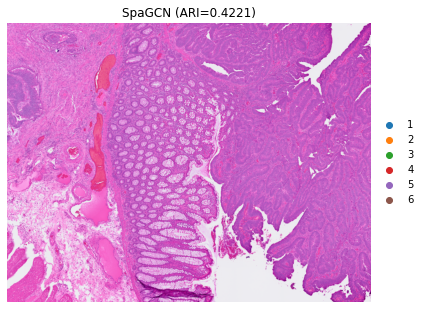

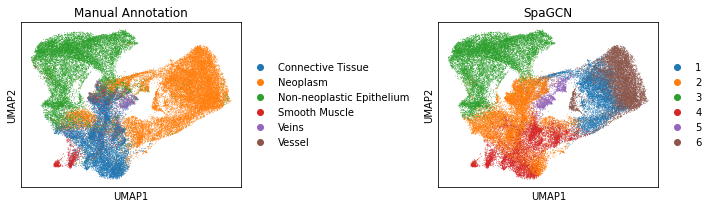

In [12]:
# Refinement on grid coords; square neighbors for 16 um HD bins
adj_2d = spg.calculate_adj_matrix(x=x_array, y=y_array, histology=False)
refined_pred = spg.refine(
    sample_id=adata.obs.index.tolist(),
    pred=adata.obs['pred'].tolist(),
    dis=adj_2d,
    shape='square',
)
adata.obs['refined_pred'] = refined_pred
adata.obs['refined_pred'] = adata.obs['refined_pred'].astype('category')

sc.pp.neighbors(adata, n_neighbors=10)
sc.tl.umap(adata)

time_taken = time.time() - time_start
_, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
memory_used = peak / (1024 ** 2)

results = evaluate_clustering(
    adata, Ann_df, time_taken, memory_used, str(dir_out),
    pred_key='refined_pred', gt_df_key='fine_annot_type',
)
ARI = results['ARI']
print(f'ARI = {ARI:.4f}')

adata.obs['pred_shift'] = (adata.obs['refined_pred'].astype(int) + 1).astype(str)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    adata, color='pred_shift', library_id=library_id,
    spot_size=2, ax=ax, show=False,
)
ax.set_title(f'SpaGCN (ARI={ARI:.4f})')
ax.axis('off')
plt.tight_layout()
plt.savefig(dir_out / 'clustering.pdf', dpi=300, bbox_inches='tight')

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sc.pl.umap(adata, color='Ground Truth', ax=axes[0], show=False)
sc.pl.umap(adata, color='pred_shift', ax=axes[1], show=False)
axes[0].set_title('Manual Annotation')
axes[1].set_title('SpaGCN')
plt.tight_layout()
plt.savefig(dir_out / 'umap.pdf', dpi=300, bbox_inches='tight')

if 'X_pca' not in adata.obsm:
    sc.tl.pca(adata, n_comps=50)
pd.DataFrame(adata.obsm['X_pca'], index=adata.obs.index).to_csv(
    dir_out / 'low_dim_data.csv', index=False,
)
adata.obs.to_csv(dir_out / 'cell_metadata.csv')
umap_df = pd.DataFrame(adata.obsm['X_umap'], columns=['UMAP1', 'UMAP2'])
umap_df['spot_id'] = adata.obs_names
umap_df[['spot_id', 'UMAP1', 'UMAP2']].to_csv(
    dir_out / 'spatial_umap_coords.csv', index=False,
)

del adj, adj_2d, clf, adata
torch.cuda.empty_cache()